# Landscape scan — frustrated ring N=7, LZS(M=2) optimal control

Workflow (mirrors Pecci, Wang, Torta, Mbeng & Santoro, *"Beyond Quantum Annealing"*, App. C):

1. **Multi-restart** the GRAPE optimizer from several random seeds to find distinct local minima $\theta^*$ in the 7-dim LZS parameter space.
2. **Hessian** of $E(\theta)$ at a chosen $\theta^*$, via finite differences on the analytic GRAPE gradient (cheap — the gradient itself is exact).
3. **2D slice** of the landscape along the Hessian's stiffest/softest eigendirections, evaluating $E$, $M_2$ (SRE / magic), and $S_{vN}$ (entanglement) of the *final* state at every grid point.
4. Cross-check against a **random-direction** slice.

Self-contained: rebuilds the frustrated-ring Hamiltonians and Z2 +1-sector exactly as in `FrustratedRing.ipynb` (N=7, J=1.0, JL=0.5, JR=0.45, tau=50).

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from tqdm import trange

from src.annealing_utils import get_longitudinal_hamiltonian, get_driver_hamiltonian
from src.utils import Z2SymmetricSector, EntanglementEntropy
from src.jax_utils import SREJax
from src.sparse_grape_method import SparseGRAPEModel, SparseGRAPETrainer

## Hamiltonian setup — frustrated ring, N=7

In [2]:
def frustrated_ring_jij_hz(N, J=1.0, JL=0.5, JR=0.45):
    """
    Build (jij, hz) for get_longitudinal_hamiltonian(jij, hz):
        H_p = -sum_{j=1}^N J_j Z_j Z_{j+1}   (site N+1 == site 1, 1-indexed j)
        J_j = -J_R if j==N ; J_L if j==(N-1)/2 or (N+1)/2 ; J otherwise
    """
    assert N % 2 == 1, "N must be odd"
    jij = np.zeros((N, N))
    mid1 = (N - 1) // 2
    mid2 = (N + 1) // 2
    for j in range(1, N + 1):
        if j == N:
            Jj = -JR
        elif j == mid1 or j == mid2:
            Jj = JL
        else:
            Jj = J
        i0 = j - 1
        i1 = j % N
        jij[i0, i1] += -Jj
        jij[i1, i0] += -Jj
    hz = np.zeros(N)
    return jij, hz


N = 7
J, JL, JR = 1.0, 0.5, 0.45
nqubits = N

jij, hz = frustrated_ring_jij_hz(N, J, JL, JR)
target_hamiltonian = get_longitudinal_hamiltonian(jij, hz)  # sparse, full 2^N
driver_hamiltonian = get_driver_hamiltonian(nqubits=nqubits)  # sparse, full 2^N

E0_formula = -(N - 3) * J + JR - 2 * JL
vals_full = np.sort(
    eigsh(
        target_hamiltonian.astype(complex), k=4, which="SA", return_eigenvectors=False
    )
)
print(f"E0 formula          : {E0_formula:.4f}")
print(f"E0,E1 numeric (full) : {np.round(vals_full, 4)}")

E0 formula          : -4.5500
E0,E1 numeric (full) : [-4.55 -4.55 -4.45 -4.45]


## Z2 +1-sector projection

Uses `Z2SymmetricSector` (the correct symmetric/antisymmetric-combination isometry, NOT `src.utils.Sector`'s naive index truncation).

In [3]:
sector = Z2SymmetricSector(nqubits, sign=+1)
dim = 2**nqubits

psi_init_full = np.ones(dim, dtype=complex) / np.sqrt(dim)
assert sector.check_confined(psi_init_full), "initial state not confined to +1 sector!"

target_hamiltonian_s = sector.project(target_hamiltonian)
driver_hamiltonian_s = sector.project(driver_hamiltonian)
psi_init_s = sector.project(psi_init_full)

print(f"Full space dim : {dim}")
print(f"Sector dim     : {sector.dim_sector}")
print(f"psi_init_s norm: {np.linalg.norm(psi_init_s):.10f}")

Z2SymmetricSector: 64 states out of 128 (sign=+1)
Full space dim : 128
Sector dim     : 64
psi_init_s norm: 1.0000000000


## Schedule hyperparameters — LZS(M=2), 7 parameters

In [62]:
tau = 80
time_steps = int(30 * tau)
number_parameters = 2  # M=2 plateaus/arms -> n_params = 3*M+1 = 7
schedule_type = "LZS"


def build_model(seed=42, random=False):
    return SparseGRAPEModel(
        initial_state=psi_init_s,
        target_hamiltonian=target_hamiltonian_s,
        initial_hamiltonian=driver_hamiltonian_s,
        reference_hamiltonian=target_hamiltonian_s,
        tf=tau,
        number_of_parameters=number_parameters,
        nsteps=time_steps,
        type=schedule_type,
        seed=seed,
        random=random,
    )

## Step 1 — multi-restart to find distinct local minima

L-BFGS-B on the 7-param LZS landscape from `n_restarts` random seeds; converged $\theta^*$'s are deduped by L2 distance in parameter space so re-converged seeds don't count twice.

In [ ]:
def multi_restart_minima(n_restarts=20, dedupe_tol=1e-3, maxiter=500, verbose=True):
    candidates = []
    for seed in trange(n_restarts, desc="restarts"):
        model = build_model(seed=seed, random=True)
        trainer = SparseGRAPETrainer(model, maxiter=maxiter, verbose=False)
        res = trainer.run()
        candidates.append(
            {"theta": res["parameters"], "energy": res["energy"], "seed": seed}
        )

    candidates.sort(key=lambda c: c["energy"])

    minima = []
    for c in candidates:
        is_new = all(
            np.linalg.norm(c["theta"] - m["theta"]) > dedupe_tol for m in minima
        )
        if is_new:
            minima.append(c)

    if verbose:
        print(f"\n{len(minima)} distinct local minima out of {n_restarts} restarts:")
        for m in minima:
            print(f"  seed={m['seed']:3d}  E={m['energy']:.6f}")
    return minima


minima = multi_restart_minima(n_restarts=10, verbose=True)
theta_star = minima[0]["theta"]  # best (lowest-energy) minimum found
print("\nUsing theta* from the best minimum:", theta_star)

restarts: 100%|██████████| 10/10 [20:46<00:00, 124.62s/it]


10 distinct local minima out of 10 restarts:
  seed=  4  E=-4.547811
  seed=  9  E=-4.527966
  seed=  7  E=-4.491205
  seed=  2  E=-4.485521
  seed=  0  E=-4.483447
  seed=  1  E=-4.482679
  seed=  5  E=-4.482406
  seed=  8  E=-4.482372
  seed=  3  E=-4.481697
  seed=  6  E=-4.478883

Using theta* from the best minimum: [ 1.35129381  1.78485987  1.10468844 -1.85158927  0.74701161 16.26347472
  0.80384815]


##### Analysis of local minima

In [80]:
# set the model
model = SparseGRAPEModel(
    initial_state=psi_init_s,
    target_hamiltonian=target_hamiltonian_s,
    initial_hamiltonian=driver_hamiltonian_s,
    reference_hamiltonian=target_hamiltonian_s,
    tf=tau,
    number_of_parameters=number_parameters,
    nsteps=time_steps,
    type=schedule_type,
    seed=42,
    random=True,
)
print(tau, time_steps)

print(minima[1]["theta"].shape)
idx_minima_init = 0
idx_minima_final = 5
# set the condition
lambd = np.linspace(0, 1, 10)
thetas = (
    lambd[:, None] * minima[idx_minima_final]["theta"]
    + (1 - lambd[:, None]) * minima[idx_minima_init]["theta"]
)

print(thetas[0], thetas[-1])

80 2400
(7,)
[ 1.35129381  1.78485987  1.10468844 -1.85158927  0.74701161 16.26347472
  0.80384815] [-0.16826844  0.43975678 -0.23054201  0.58949315 -0.2661376  -0.35057759
  0.40915037]


In [78]:
from scipy.sparse.linalg import expm_multiply, eigsh
from src.jax_utils import SREJax
from src.utils import EntanglementEntropy
from src.utils_visualization import propagate_trajectory

sre = SREJax(nqubits)
ent = EntanglementEntropy(nqubits)
time_subsample = 20


# ── instantaneous GS/1st-excited of the LINEAR-schedule Hamiltonian, ──
# ── evaluated at each sampled time — common reference frame, computed once ──
def linear_instantaneous_eigenstates(t_sub, tf, driver_h, target_h, sector):
    eig0_full, eig1_full, E0_lin, E1_lin = [], [], [], []
    for t in t_sub:
        s = t / tf
        H_lin_t = (1 - s) * driver_h + s * target_h
        evals, evecs = eigsh(H_lin_t, k=2, which="SA")
        order = np.argsort(evals)
        evals, evecs = evals[order], evecs[:, order]
        v0 = sector.lift(evecs[:, 0] / np.linalg.norm(evecs[:, 0]))
        v1 = sector.lift(evecs[:, 1] / np.linalg.norm(evecs[:, 1]))
        eig0_full.append(v0 / np.linalg.norm(v0))
        eig1_full.append(v1 / np.linalg.norm(v1))
        E0_lin.append(evals[0])
        E1_lin.append(evals[1])
    return np.array(eig0_full), np.array(eig1_full), np.array(E0_lin), np.array(E1_lin)


# t_sub is the same for every theta (same tau, time_steps, time_subsample),
# so grab it once via a throwaway forward pass, then reuse.
model.parameters = thetas[0]
model.forward_and_gradient(thetas[0])
_, t_sub_ref = propagate_trajectory(
    model,
    thetas[0],
    sector,
    driver_hamiltonian_s,
    target_hamiltonian_s,
    time_subsample=time_subsample,
    psi_init_s=psi_init_s,
)

eig0_lin_t, eig1_lin_t, E0_lin_t, E1_lin_t = linear_instantaneous_eigenstates(
    t_sub_ref, tau, driver_hamiltonian_s, target_hamiltonian_s, sector
)
print(
    f"instantaneous linear gap at t=0: {E1_lin_t[0]-E0_lin_t[0]:.4f}, "
    f"at t=tau: {E1_lin_t[-1]-E0_lin_t[-1]:.4f}"
)

# ── linear-schedule driving (reference), computed once ──
h_driver_lin = 1.0 - model.time / tau
h_target_lin = model.time / tau

# ── theta interpolation sweep ──
results = []
model.parameters = thetas[0]
h_driver_init, h_target_init = model.get_driving()
model.parameters = thetas[-1]
h_driver_final, h_target_final = model.get_driving()


for i, theta in enumerate(thetas):
    model.parameters = theta
    E, _ = model.forward_and_gradient(theta)
    h_driver = lambd[i] * h_driver_final + (1 - lambd[i]) * h_driver_init
    h_target = lambd[i] * h_target_final + (1 - lambd[i]) * h_target_init

    h_driver, h_target = model.get_driving()  # (nsteps,) each, full resolution

    psi_hist, t_sub = propagate_trajectory(
        model,
        theta,
        sector,
        driver_hamiltonian_s,
        target_hamiltonian_s,
        time_subsample=time_subsample,
        psi_init_s=psi_init_s,
    )
    assert np.allclose(t_sub, t_sub_ref), "time grid mismatch across theta"

    m2_t = np.array([sre(psi) for psi in psi_hist])
    s_t = np.array([ent.von_neumann(psi) for psi in psi_hist])
    P0_t = np.array(
        [np.abs(np.vdot(eig0_lin_t[k], psi_hist[k])) ** 2 for k in range(len(t_sub))]
    )
    P1_t = np.array(
        [np.abs(np.vdot(eig1_lin_t[k], psi_hist[k])) ** 2 for k in range(len(t_sub))]
    )

    T_window = t_sub[-1] - t_sub[0]
    m2_produced = np.trapz(m2_t, t_sub) / T_window
    S_produced = np.trapz(s_t, t_sub) / T_window

    results.append(
        {
            "lambda": lambd[i],
            "theta": theta,
            "t_sub": t_sub,
            "time": model.time.copy(),
            "h_driver": h_driver,
            "h_target": h_target,  # optimal-control schedule
            "E_final": E,
            "P0_t": P0_t,
            "P1_t": P1_t,
            "P0_final": P0_t[-1],
            "P1_final": P1_t[-1],
            "m2_t": m2_t,
            "m2_final": m2_t[-1],
            "m2_produced": m2_produced,
            "S_t": s_t,
            "S_final": s_t[-1],
            "S_produced": S_produced,
        }
    )

    print(
        f"[λ={lambd[i]:.2f}] E={E:.6f}  P0(T)={P0_t[-1]:.4f}  P1(T)={P1_t[-1]:.4f}  "
        f"<M2>={m2_produced:.4f}  <S>={S_produced:.4f}"
    )

Building Pauli index tables for n=7 (16,384 Paulis)...
Done.
Bipartition: A=3 qubits (8d), B=4 qubits (16d)
instantaneous linear gap at t=0: 4.0000, at t=tau: 0.0913


/tmp/ipykernel_933/2721132024.py:93: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  m2_produced = np.trapz(m2_t, t_sub) / T_window
/tmp/ipykernel_933/2721132024.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  S_produced = np.trapz(s_t, t_sub) / T_window


[λ=0.00] E=-4.547811  P0(T)=0.9891  P1(T)=0.0098  <M2>=0.8498  <S>=0.5159
[λ=0.11] E=-4.544009  P0(T)=0.9610  P1(T)=0.0375  <M2>=0.8668  <S>=0.5211
[λ=0.22] E=-4.528928  P0(T)=0.8466  P1(T)=0.1495  <M2>=0.9318  <S>=0.5261
[λ=0.33] E=-4.499690  P0(T)=0.6082  P1(T)=0.3836  <M2>=1.0288  <S>=0.5277
[λ=0.44] E=-4.465579  P0(T)=0.2824  P1(T)=0.7066  <M2>=1.0380  <S>=0.5260
[λ=0.56] E=-4.451215  P0(T)=0.1202  P1(T)=0.8697  <M2>=1.0044  <S>=0.5400
[λ=0.67] E=-4.488442  P0(T)=0.5322  P1(T)=0.4563  <M2>=1.1572  <S>=0.5679
[λ=0.78] E=-4.497312  P0(T)=0.6393  P1(T)=0.3492  <M2>=1.1923  <S>=0.5018
[λ=0.89] E=-4.472000  P0(T)=0.5301  P1(T)=0.4450  <M2>=1.2479  <S>=0.5837
[λ=1.00] E=-4.482679  P0(T)=0.3527  P1(T)=0.6457  <M2>=0.9342  <S>=0.2180


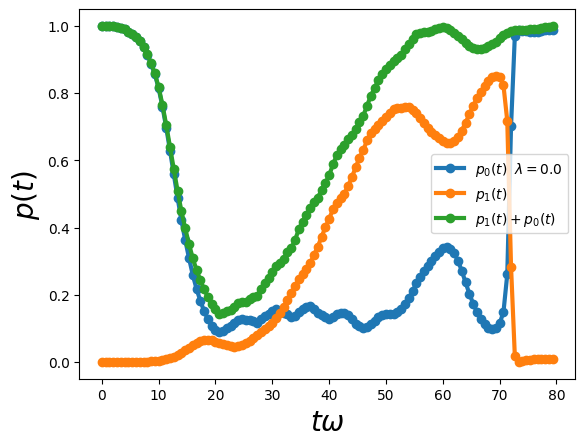

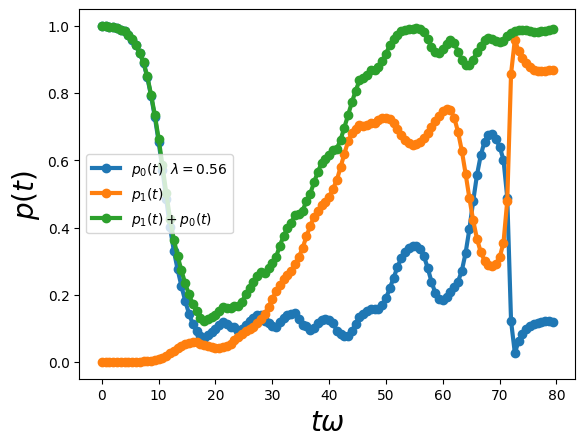

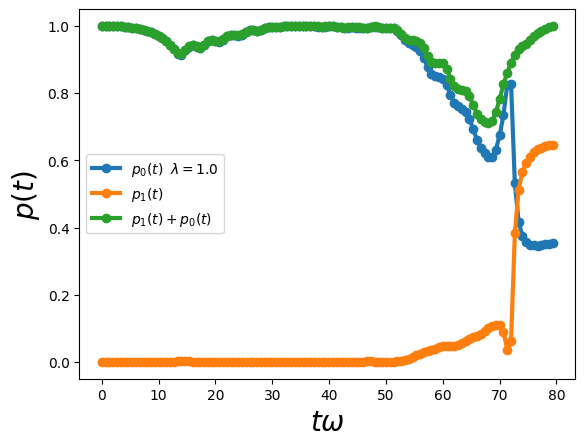

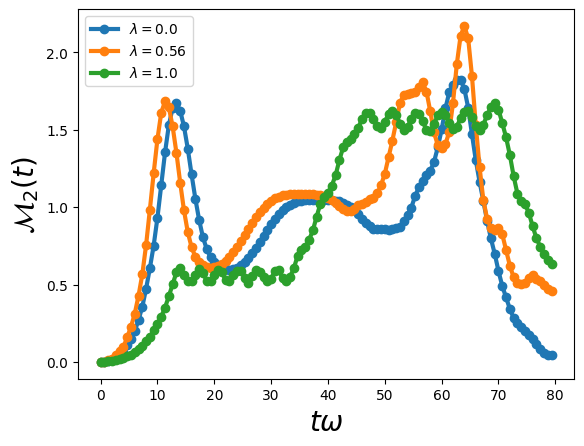

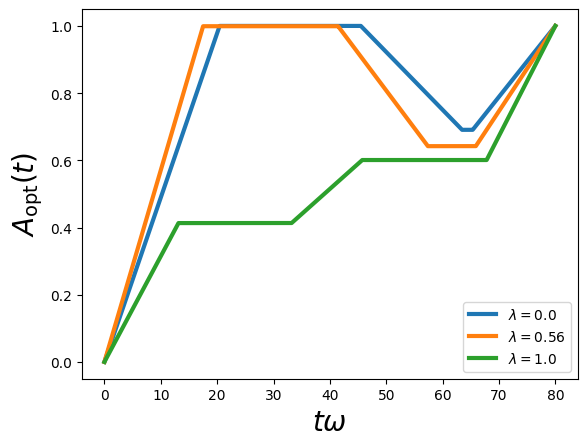

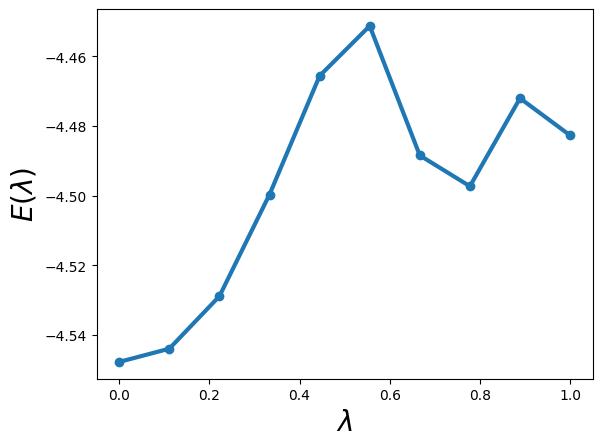

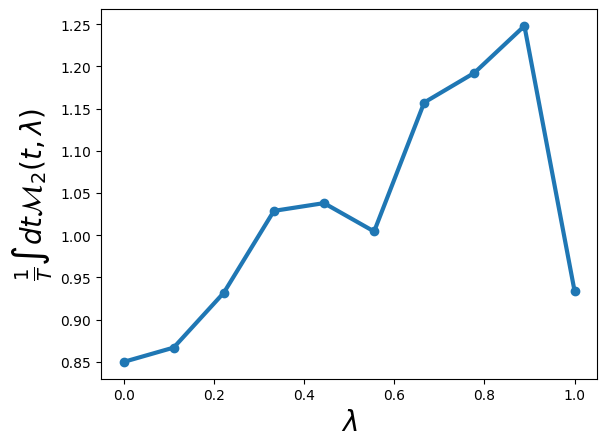

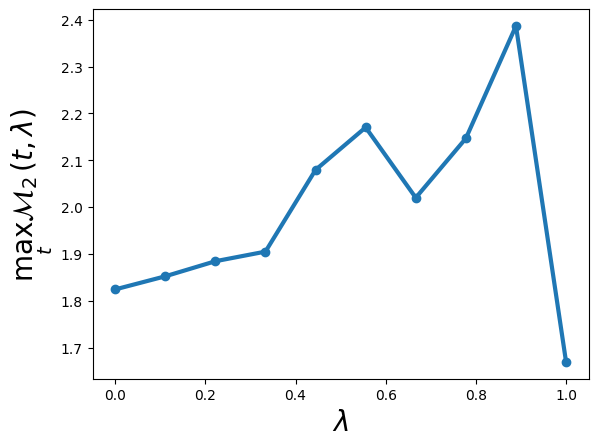

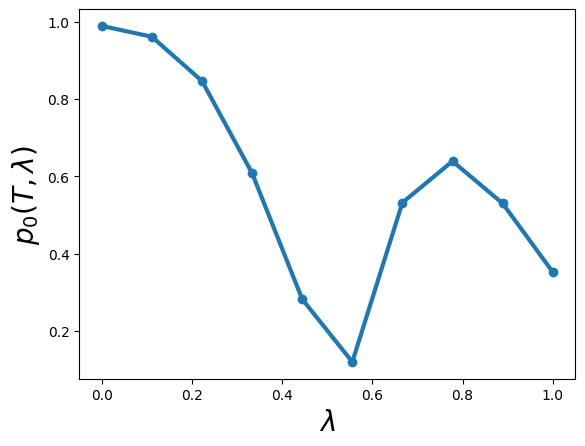

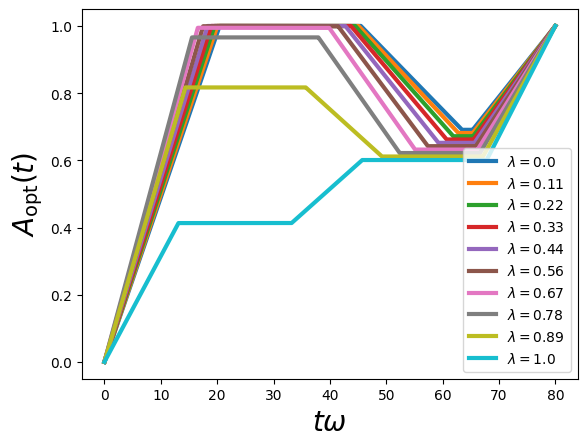

In [79]:
energy_landscape = []
magic_landscape = []
max_magic_landscape = []
entanglement_landscape = []
final_probability_landscape = []
for i in range(len(results)):
    r = results[i]
    energy_landscape.append(r["E_final"])
    magic_landscape.append(r["m2_produced"])
    max_magic_landscape.append(np.max(r["m2_t"]))
    final_probability_landscape.append(r["P0_final"])
    if i == 0 or i == len(results) - 1 or i == len(results) // 2:
        plt.plot(
            t_sub,
            r["P0_t"],
            label=r"$p_0(t) \; \;  \lambda=$" + f"{lambd[i]:.2}",
            linewidth=3,
            marker="o",
        )
        plt.plot(
            t_sub,
            r["P1_t"],
            label=r"$p_1(t)$",
            linewidth=3,
            marker="o",
        )
        plt.plot(
            t_sub,
            r["P1_t"] + r["P0_t"],
            label=r"$p_1(t)+p_0(t)$",
            linewidth=3,
            marker="o",
        )
        plt.xlabel(r"$t\omega$", fontsize=20)
        plt.ylabel(r"$p(t)$", fontsize=20)
        plt.legend(fontsize=10)
        plt.show()

for i in range(len(results)):
    r = results[i]
    if i == 0 or i == len(results) - 1 or i == len(results) // 2:
        plt.plot(
            t_sub,
            r["m2_t"],
            label=r"$\lambda=$" + f"{lambd[i]:.2}",
            linewidth=3,
            marker="o",
        )
        plt.xlabel(r"$t\omega$", fontsize=20)
        plt.ylabel(r"$\mathcal{M}_2(t)$", fontsize=20)
        plt.legend(fontsize=10)
plt.show()

for i in range(len(results)):
    r = results[i]
    if i == 0 or i == len(results) - 1 or i == len(results) // 2:
        plt.plot(
            model.time,
            r["h_target"],
            label=r"$\lambda=$" + f"{lambd[i]:.2}",
            linewidth=3,
        )
        plt.xlabel(r"$t\omega$", fontsize=20)
        plt.ylabel(r"$A_{\text{opt}}(t)$", fontsize=20)
        plt.legend(fontsize=10)
plt.show()


plt.plot(lambd, energy_landscape, linewidth=3, marker="o")
plt.xlabel(r"$\lambda$", fontsize=20)
plt.ylabel(r"$E(\lambda)$", fontsize=20)
plt.show()

plt.plot(lambd, magic_landscape, linewidth=3, marker="o")
plt.xlabel(r"$\lambda$", fontsize=20)
plt.ylabel(r"$\frac{1}{T}\int dt \mathcal{M}_2(t,\lambda)$", fontsize=20)
plt.show()

plt.plot(lambd, max_magic_landscape, linewidth=3, marker="o")
plt.xlabel(r"$\lambda$", fontsize=20)
plt.ylabel(r"$\max_t \mathcal{M}_2(t,\lambda)$", fontsize=20)
plt.show()

plt.plot(lambd, final_probability_landscape, linewidth=3, marker="o")
plt.xlabel(r"$\lambda$", fontsize=20)
plt.ylabel(r"$p_0(T,\lambda)$", fontsize=20)

plt.show()

for i in range(lambd.shape[0]):
    r = results[i]
    plt.plot(
        model.time,
        r["h_target"],
        label=r"$\lambda=$" + f"{lambd[i]:.2}",
        linewidth=3,
    )
    plt.xlabel(r"$t\omega$", fontsize=20)
    plt.ylabel(r"$A_{\text{opt}}(t)$", fontsize=20)
    plt.legend(fontsize=10)
plt.show()

## Step 2 — Hessian at theta*, eigendirections

Central finite differences on the *analytic* GRAPE gradient (cheap — 2×7 extra gradient evaluations, not a from-scratch FD Hessian).

In [6]:
def hessian_fd(model, theta_star, eps=1e-4):
    n = len(theta_star)
    H = np.zeros((n, n))
    for i in range(n):
        tp, tm = theta_star.copy(), theta_star.copy()
        tp[i] += eps
        tm[i] -= eps
        _, gp = model.forward_and_gradient(tp)
        _, gm = model.forward_and_gradient(tm)
        H[i, :] = (gp - gm) / (2 * eps)
    H = 0.5 * (H + H.T)  # symmetrize (FD Hessian isn't exactly symmetric)
    model.forward_and_gradient(theta_star)  # reset model state
    return H


def hessian_eigendirections(model, theta_star, eps=1e-4):
    H = hessian_fd(model, theta_star, eps)
    evals, evecs = np.linalg.eigh(H)
    return evecs[:, -1], evecs[:, 0], evals  # v_max, v_min, eigenvalues


def random_orthonormal_directions(n_params, seed=0):
    rng = np.random.default_rng(seed)
    v1 = rng.normal(size=n_params)
    v1 /= np.linalg.norm(v1)
    v2 = rng.normal(size=n_params)
    v2 -= (v2 @ v1) * v1
    v2 /= np.linalg.norm(v2)
    return v1, v2


model = build_model()
v_max, v_min, evals = hessian_eigendirections(model, theta_star)
print("Hessian eigenvalues:", np.round(evals, 5))
print("Stiffest direction (v_max):", np.round(v_max, 4))
print("Softest  direction (v_min):", np.round(v_min, 4))

Hessian eigenvalues: [-3.000000e-05  7.724000e-02  1.710800e-01  3.741500e-01  6.534600e-01
  2.244010e+00  1.142264e+01]
Stiffest direction (v_max): [-0.2357 -0.0063  0.0843  0.2504 -0.0351 -0.1207 -0.9267]
Softest  direction (v_min): [ 0.4939  0.4571  0.452   0.386   0.4404  0.     -0.    ]


## Step 3 — 2D scan along Hessian eigendirections

$\theta = \theta^* + \mu\, v_{max} + \nu\, v_{min}$. At every grid point: propagate to get the final sector-state, lift it to the full $2^N$ space (SRE / entanglement are functionals of the full-space wavefunction), and record $E$, $M_2$, $S_{vN}$.

**Note on grid range**: start with a modest $\mu,\nu$ range — the LZS durations go through a softplus, so large excursions can push segments toward degenerate/near-zero duration. Widen once the first heatmap looks sensible.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Building Pauli index tables for n=7 (16,384 Paulis)...
Done.
Bipartition: A=3 qubits (8d), B=4 qubits (16d)


landscape scan: 100%|██████████| 25/25 [04:32<00:00, 10.89s/it]


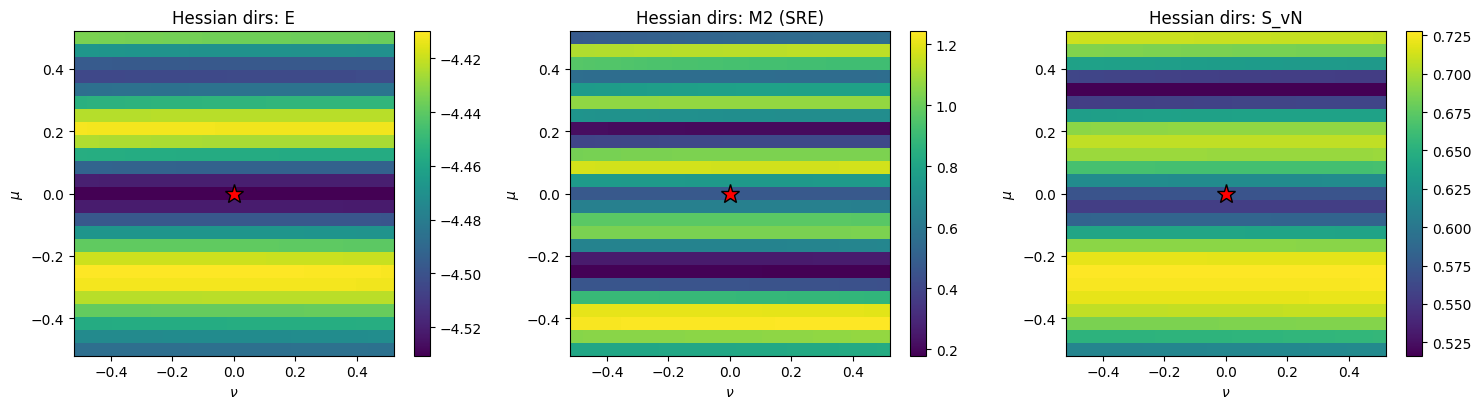

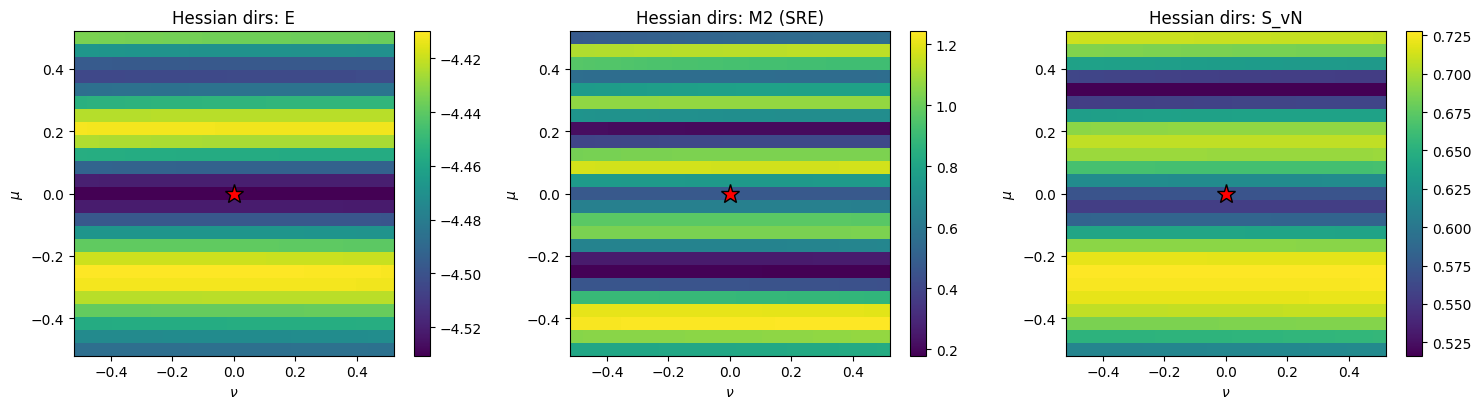

In [ ]:
from scipy.sparse.linalg import expm_multiply


def propagate_trajectory(
    model,
    theta,
    sector,
    driver_hamiltonian_s,
    target_hamiltonian_s,
    time_subsample=10,
    psi_init_s=None,
):
    """
    Full time-resolved propagation for a given theta. Returns psi_history_full
    (n_sub_steps, 2^n) — the state lifted to the full space at each *sampled*
    time step, plus the corresponding subsampled time indices.

    time_subsample: keep every k-th step. SRE is not free (4^n Paulis per
    call), so sampling every ~10-20 steps out of nsteps=500 is usually enough
    to resolve the magic profile without recomputing all 500.
    """
    model.forward_and_gradient(theta)  # syncs h_driver/h_target for this theta
    h_driver, h_target = model.get_driving()
    dt = model.dt

    idx = np.arange(0, model.nsteps, time_subsample)
    psi = psi_init_s.copy()
    psi_history_full = np.zeros((len(idx), sector.dim), dtype=complex)

    k = 0
    for i in range(model.nsteps):
        H_t = h_driver[i] * driver_hamiltonian_s + h_target[i] * target_hamiltonian_s
        psi = expm_multiply(-1j * dt * H_t, psi)
        if i in idx:
            psi_full = sector.lift(psi)
            psi_history_full[k] = psi_full / np.linalg.norm(psi_full)
            k += 1

    return psi_history_full, model.time[idx]


def scan_2d(
    model,
    center,
    v1,
    v2,
    sector,
    n_qubits,
    mu_range,
    nu_range,
    driver_hamiltonian_s,
    target_hamiltonian_s,
    psi_init_s=None,
    time_subsample=10,
    verbose=True,
):
    sre = SREJax(n_qubits)
    ent = EntanglementEntropy(n_qubits)
    nM, nN = len(mu_range), len(nu_range)

    E_grid = np.zeros((nM, nN))

    M2_mean_grid = np.zeros((nM, nN))
    M2_max_grid = np.zeros((nM, nN))
    M2_integral_grid = np.zeros((nM, nN))
    M2_final_grid = np.zeros((nM, nN))

    S_mean_grid = np.zeros((nM, nN))
    S_max_grid = np.zeros((nM, nN))
    S_integral_grid = np.zeros((nM, nN))
    S_final_grid = np.zeros((nM, nN))

    for i in trange(nM, desc="trajectory scan", disable=not verbose):
        for j in range(nN):
            theta = center + mu_range[i] * v1 + nu_range[j] * v2

            # energy: single cheap forward pass, no need for the full trajectory
            E, _ = model.forward_and_gradient(theta)
            E_grid[i, j] = E

            # full time-resolved propagation for magic + entanglement
            psi_hist, t_sub = propagate_trajectory(
                model,
                theta,
                sector,
                driver_hamiltonian_s,
                target_hamiltonian_s,
                time_subsample=time_subsample,
                psi_init_s=psi_init_s,
            )
            m2_t = np.array([sre(psi) for psi in psi_hist])
            s_t = np.array([ent.von_neumann(psi) for psi in psi_hist])

            M2_mean_grid[i, j] = m2_t.mean()
            M2_max_grid[i, j] = m2_t.max()
            M2_integral_grid[i, j] = np.trapz(m2_t, t_sub) / (t_sub[-1] - t_sub[0])
            M2_final_grid[i, j] = m2_t[-1]

            S_mean_grid[i, j] = s_t.mean()
            S_max_grid[i, j] = s_t.max()
            S_integral_grid[i, j] = np.trapz(s_t, t_sub) / (t_sub[-1] - t_sub[0])
            S_final_grid[i, j] = s_t[-1]

    model.forward_and_gradient(center)  # reset model state

    return {
        "E": E_grid,
        "M2_mean": M2_mean_grid,
        "M2_max": M2_max_grid,
        "M2_integral": M2_integral_grid,
        "M2_final": M2_final_grid,
        "S_mean": S_mean_grid,
        "S_max": S_max_grid,
        "S_integral": S_integral_grid,
        "S_final": S_final_grid,
    }


def plot_scan(mu_range, nu_range, E_grid, M2_grid, S_grid, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, grid, label in zip(
        axes, [E_grid, M2_grid, S_grid], ["E", "M2 (SRE)", "S_vN"]
    ):
        im = ax.pcolormesh(nu_range, mu_range, grid, shading="auto", cmap="viridis")
        ax.plot(0, 0, marker="*", color="red", markersize=14, markeredgecolor="k")
        ax.set_xlabel(r"$\nu$")
        ax.set_ylabel(r"$\mu$")
        ax.set_title(f"{title_prefix}{label}")
        fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()
    return fig


mu_range = np.linspace(-0.5, 0.5, 25)
nu_range = np.linspace(-0.5, 0.5, 25)

E_hess, M2_hess, S_hess = scan_2d(
    model, theta_star, v_max, v_min, sector, nqubits, mu_range, nu_range
)
plot_scan(mu_range, nu_range, E_hess, M2_hess, S_hess, title_prefix="Hessian dirs: ")

## Step 4 — cross-check: random-direction slice

Is the Hessian-eigendirection picture representative of the landscape around $\theta^*$, or does it sit in an unusually shaped basin? Compare against two random orthonormal directions.

Building Pauli index tables for n=7 (16,384 Paulis)...
Done.
Bipartition: A=3 qubits (8d), B=4 qubits (16d)


landscape scan: 100%|██████████| 25/25 [05:07<00:00, 12.29s/it]


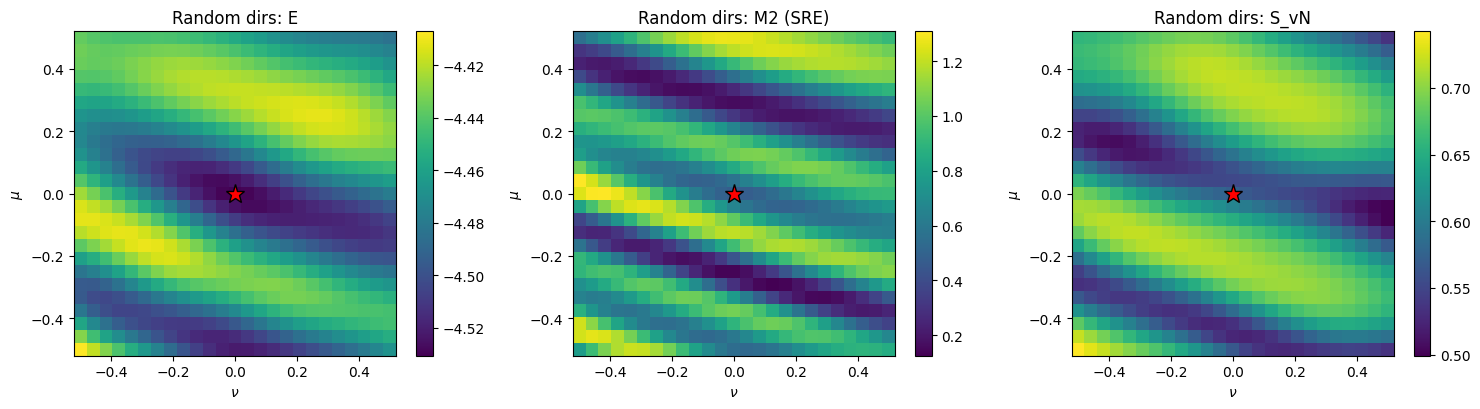

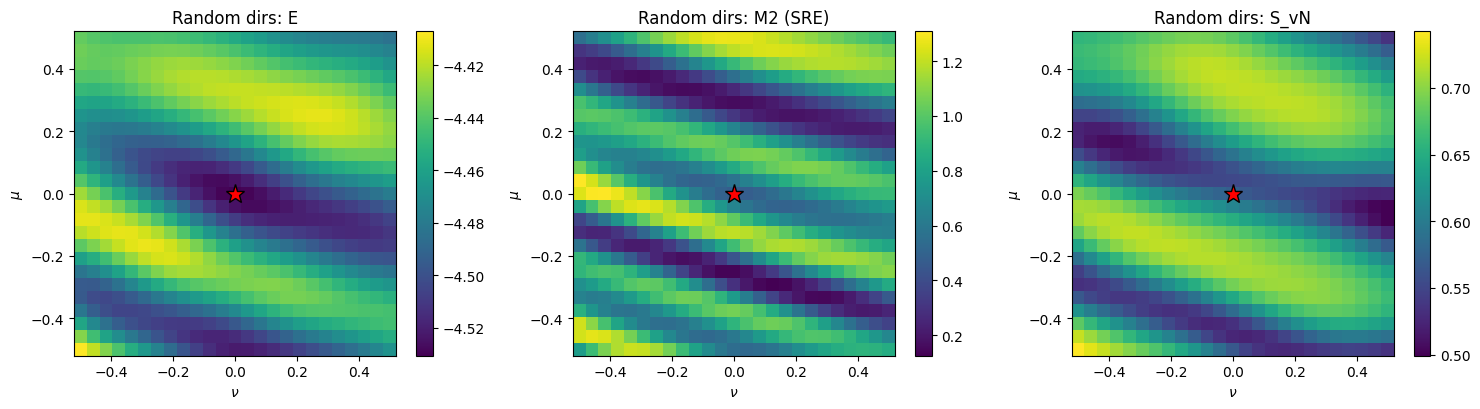

In [8]:
v1_rand, v2_rand = random_orthonormal_directions(len(theta_star), seed=0)

E_rand, M2_rand, S_rand = scan_2d(
    model, theta_star, v1_rand, v2_rand, sector, nqubits, mu_range, nu_range
)
plot_scan(mu_range, nu_range, E_rand, M2_rand, S_rand, title_prefix="Random dirs: ")